# News Topic Classifier Using BERT — AG News

## Objective
Fine-tune `bert-base-uncased` on the AG News dataset to classify news headlines into topic categories, evaluate with accuracy and F1-score, and prepare a lightweight Gradio demo for live interaction.

## Notebook Plan
1. Load and inspect the AG News dataset  
2. Visualize class balance and headline length  
3. Tokenize and preprocess text  
4. Fine-tune BERT with Hugging Face Transformers  
5. Evaluate using accuracy, F1-score, and confusion matrix  
6. Test on real headlines  
7. Save the model and provide a Gradio demo

In [13]:
# Optional installs (uncomment if needed in your Kaggle environment)
# !pip -q install transformers datasets accelerate evaluate gradio

import os
import re
import json
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from datasets import load_dataset, DatasetDict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cuda


In [14]:
# ============================================================
# CONFIG
# ============================================================

MODEL_NAME = "bert-base-uncased"
OUTPUT_DIR = Path("/kaggle/working/ag_news_bert")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
EPOCHS = 3
SAVE_TOTAL_LIMIT = 2

# Use a smaller subset for quick debugging if needed
MAX_TRAIN_SAMPLES = None  # e.g. 20000 for a fast run
MAX_TEST_SAMPLES = None   # e.g. 2000 for a fast run

print("Model:", MODEL_NAME)
print("Output dir:", OUTPUT_DIR)
print("Max length:", MAX_LENGTH)

Model: bert-base-uncased
Output dir: /kaggle/working/ag_news_bert
Max length: 128


In [15]:
# ============================================================
# LOAD DATASET
# ============================================================

dataset = load_dataset("ag_news")
print(dataset)

label_names = ["World", "Sports", "Business", "Sci/Tech"]
id2label = {i: name for i, name in enumerate(label_names)}
label2id = {name: i for i, name in enumerate(label_names)}

print("Label mapping:", id2label)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Label mapping: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


In [16]:
# ============================================================
# QUICK INSPECTION
# ============================================================

train_df = dataset["train"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())

print("\nTrain label distribution:")
display(train_df["label"].value_counts().sort_index().rename(index=id2label))

Train shape: (120000, 2)
Test shape: (7600, 2)


,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2



Train label distribution:


label
World       30000
Sports      30000
Business    30000
Sci/Tech    30000
Name: count, dtype: int64

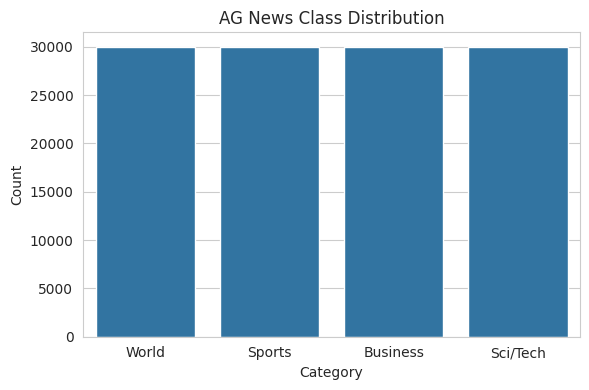

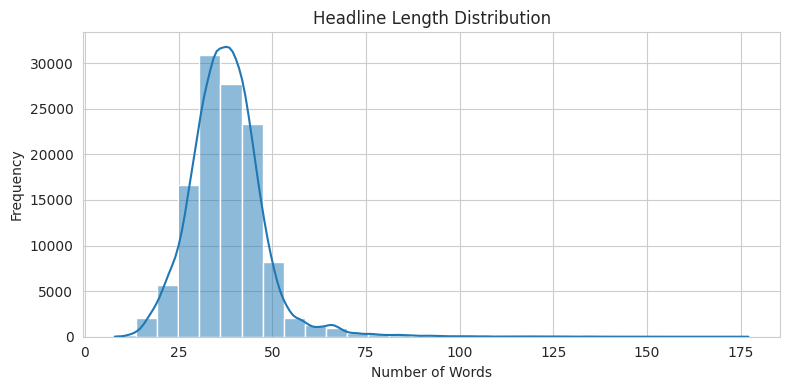

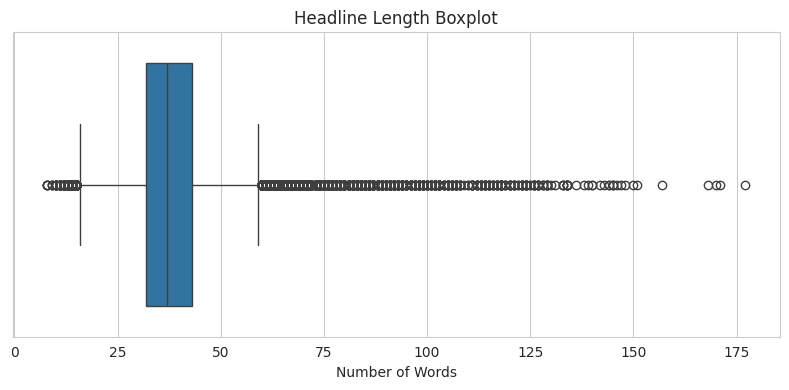

In [17]:
# ============================================================
# EXPLORATORY DATA ANALYSIS
# ============================================================

plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=train_df)
plt.xticks(ticks=[0, 1, 2, 3], labels=label_names)
plt.title("AG News Class Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

train_df["headline_len_words"] = train_df["text"].astype(str).str.split().apply(len)

plt.figure(figsize=(8, 4))
sns.histplot(train_df["headline_len_words"], bins=30, kde=True)
plt.title("Headline Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=train_df["headline_len_words"])
plt.title("Headline Length Boxplot")
plt.xlabel("Number of Words")
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# OPTIONAL SAMPLE VISUALIZATION OF HEADLINES
# ============================================================

sample_examples = train_df.sample(8, random_state=SEED)[["text", "label"]].copy()
sample_examples["category"] = sample_examples["label"].map(id2label)

display(sample_examples)

,text,label,category
71787,"BBC set for major shake-up, claims newspaper L...",2,Business
67218,Marsh averts cash crunch Embattled insurance b...,2,Business
54066,"Jeter, Yankees Look to Take Control (AP) AP - ...",1,Sports
7168,Flying the Sun to Safety When the Genesis caps...,3,Sci/Tech
29618,Stocks Seen Flat as Nortel and Oil Weigh NEW ...,2,Business
101425,Inter Milan seeks redemption win against Juven...,1,Sports
20441,Saudi Arabia cuts oil prices Oil prices eased ...,2,Business
2662,"Google Cuts Its IPO Price Range SAN JOSE, Cali...",0,World


In [19]:
# ============================================================
# TRAIN / VALIDATION SPLIT
# ============================================================

train_split, val_split = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["label"]
)

if MAX_TRAIN_SAMPLES is not None and len(train_split) > MAX_TRAIN_SAMPLES:
    train_split = train_split.sample(n=MAX_TRAIN_SAMPLES, random_state=SEED)

if MAX_TEST_SAMPLES is not None and len(test_df) > MAX_TEST_SAMPLES:
    test_df = test_df.sample(n=MAX_TEST_SAMPLES, random_state=SEED)

train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train:", train_split.shape)
print("Validation:", val_split.shape)
print("Test:", test_df.shape)

print("\nTrain label counts:")
display(train_split["label"].value_counts().sort_index().rename(index=id2label))

Train: (96000, 3)
Validation: (24000, 3)
Test: (7600, 2)

Train label counts:


label
World       24000
Sports      24000
Business    24000
Sci/Tech    24000
Name: count, dtype: int64

In [20]:
# ============================================================
# TOKENIZATION
# ============================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LENGTH
    )

# Convert pandas to Hugging Face datasets
from datasets import Dataset

train_hf = Dataset.from_pandas(train_split[["text", "label"]], preserve_index=False)
val_hf = Dataset.from_pandas(val_split[["text", "label"]], preserve_index=False)
test_hf = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

train_hf = train_hf.map(tokenize_batch, batched=True)
val_hf = val_hf.map(tokenize_batch, batched=True)
test_hf = test_hf.map(tokenize_batch, batched=True)

train_hf = train_hf.rename_column("label", "labels")
val_hf = val_hf.rename_column("label", "labels")
test_hf = test_hf.rename_column("label", "labels")

cols_to_keep = ["input_ids", "attention_mask", "labels"]
train_hf.set_format(type="torch", columns=cols_to_keep)
val_hf.set_format(type="torch", columns=cols_to_keep)
test_hf.set_format(type="torch", columns=cols_to_keep)

print(train_hf)
print(val_hf)
print(test_hf)

Map:   0%|          | 0/96000 [00:00<?, ? examples/s]

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 96000
})
Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 24000
})
Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 7600
})


In [21]:
# ============================================================
# MODEL DEFINITION
# ============================================================

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label=id2label,
    label2id={v: k for k, v in id2label.items()}
).to(DEVICE)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Model and data collator ready.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model and data collator ready.


In [22]:
# ============================================================
# TRAINING ARGUMENTS
# ============================================================

import inspect
ta_params = inspect.signature(TrainingArguments.__init__).parameters

training_kwargs = dict(
    output_dir=str(OUTPUT_DIR),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    save_total_limit=SAVE_TOTAL_LIMIT,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    logging_steps=100,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
    remove_unused_columns=False,
)

# Handle version differences in transformers
if "evaluation_strategy" in ta_params:
    training_kwargs["evaluation_strategy"] = "epoch"
else:
    training_kwargs["eval_strategy"] = "epoch"

if "save_strategy" in ta_params:
    training_kwargs["save_strategy"] = "epoch"

training_args = TrainingArguments(**training_kwargs)

print("TrainingArguments ready.")

TrainingArguments ready.


In [23]:
# ============================================================
# METRICS
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro"),
        "f1_weighted": f1_score(labels, preds, average="weighted"),
    }

print("Metric function ready.")

Metric function ready.


In [24]:
# ============================================================
# TRAINING
# ============================================================

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=val_hf,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

train_result = trainer.train()
print("Training completed.")
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.350843,0.335697,0.943875,0.943890,0.943890
2,0.259352,0.330788,0.948792,0.948910,0.948910
3,0.176549,0.383906,0.949708,0.949719,0.949719


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training completed.
TrainOutput(global_step=9000, training_loss=0.29728297000461157, metrics={'train_runtime': 3721.0541, 'train_samples_per_second': 77.397, 'train_steps_per_second': 2.419, 'total_flos': 1.5547577224817664e+16, 'train_loss': 0.29728297000461157, 'epoch': 3.0})


In [25]:
# ============================================================
# EVALUATION ON TEST SET
# ============================================================

test_pred = trainer.predict(test_hf)
test_logits = test_pred.predictions
test_labels = test_pred.label_ids
test_preds = np.argmax(test_logits, axis=-1)

test_accuracy = accuracy_score(test_labels, test_preds)
test_f1_macro = f1_score(test_labels, test_preds, average="macro")
test_f1_weighted = f1_score(test_labels, test_preds, average="weighted")

print("Test Accuracy:", round(test_accuracy, 4))
print("Test F1 Macro:", round(test_f1_macro, 4))
print("Test F1 Weighted:", round(test_f1_weighted, 4))

print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names))

Test Accuracy: 0.9429
Test F1 Macro: 0.943
Test F1 Weighted: 0.943

Classification Report:
              precision    recall  f1-score   support

       World       0.97      0.94      0.96      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.92      0.90      0.91      1900
    Sci/Tech       0.90      0.94      0.92      1900

    accuracy                           0.94      7600
   macro avg       0.94      0.94      0.94      7600
weighted avg       0.94      0.94      0.94      7600



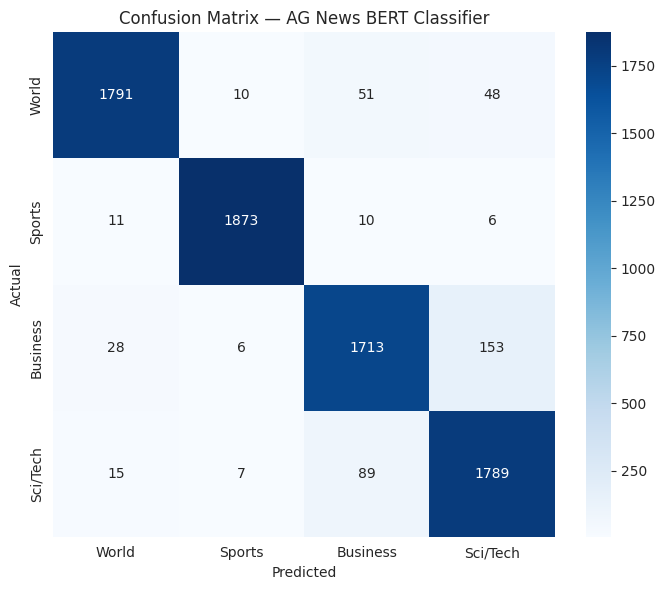

In [26]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.title("Confusion Matrix — AG News BERT Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [27]:
# ============================================================
# ERROR ANALYSIS
# ============================================================

wrong_idx = np.where(test_preds != test_labels)[0]

print("Total misclassified samples:", len(wrong_idx))

if len(wrong_idx) > 0:
    sample_wrong = np.random.RandomState(SEED).choice(
        wrong_idx,
        size=min(15, len(wrong_idx)),
        replace=False
    )

    rows = []
    probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()

    for i in sample_wrong:
        true_lab = label_names[int(test_labels[i])]
        pred_lab = label_names[int(test_preds[i])]
        top3 = np.argsort(probs[i])[-3:][::-1]
        rows.append({
            "headline": test_df.iloc[i]["text"],
            "true": true_lab,
            "predicted": pred_lab,
            "top1_prob": float(probs[i][np.argmax(test_logits[i])]),
            "top3": ", ".join([f"{label_names[j]} ({probs[i][j]:.2f})" for j in top3])
        })

    display(pd.DataFrame(rows))

Total misclassified samples: 434


,headline,true,predicted,top1_prob,top3
0,"Blame player, not game It was like nothing you...",Sci/Tech,Sports,0.997917,"Sports (1.00), World (0.00), Business (0.00)"
1,Philippines mourns dead in Russian school sieg...,Sci/Tech,World,0.998950,"World (1.00), Business (0.00), Sci/Tech (0.00)"
2,MCI Creditors Are Target Of SEC Subpoenas 11 ...,Business,Sci/Tech,0.894389,"Sci/Tech (0.89), Business (0.10), World (0.00)"
3,Amazon.com net sales jump 29; Google reports \...,Sci/Tech,Business,0.898924,"Business (0.90), Sci/Tech (0.10), World (0.00)"
4,"GAME UNDER FIRE Attacking police officers, rac...",Sci/Tech,Sports,0.979207,"Sports (0.98), World (0.01), Sci/Tech (0.01)"
5,Dow Jones Agrees to Buy MarketWatch in \$519 M...,World,Business,0.995850,"Business (1.00), Sci/Tech (0.00), World (0.00)"
6,"SIA: Chip sales to hit record, flatten Worldwi...",Business,Sci/Tech,0.919383,"Sci/Tech (0.92), Business (0.08), World (0.00)"
7,Israel to close Erez industrial zone before Ma...,Business,World,0.988824,"World (0.99), Business (0.01), Sci/Tech (0.00)"
8,Before-the-Bell: GenCorp Falls 5.6 Pct. (Reute...,Sci/Tech,Business,0.997523,"Business (1.00), World (0.00), Sci/Tech (0.00)"
9,IBM sells PC stake to China's Lenovo China's b...,Business,Sci/Tech,0.746505,"Sci/Tech (0.75), Business (0.24), World (0.01)"


In [28]:
# ============================================================
# REAL-WORLD TESTING
# ============================================================

def predict_headline(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(DEVICE)

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]

    top3 = np.argsort(probs)[-3:][::-1]
    return [
        {"label": label_names[i], "probability": float(probs[i])}
        for i in top3
    ]

real_tests = [
    "Apple unveils next generation AI chips",
    "Manchester United wins dramatic final",
    "Stock markets rally after inflation report",
    "UN announces new peace agreement",
    "Scientists discover new exoplanet with water",
    "Government introduces new tax policy"
]

for headline in real_tests:
    preds = predict_headline(headline)
    print("\nHeadline:", headline)
    for item in preds:
        print(f"  {item['label']}: {item['probability']:.2%}")


Headline: Apple unveils next generation AI chips
  Sci/Tech: 98.98%
  Business: 0.90%
  World: 0.11%

Headline: Manchester United wins dramatic final
  Sports: 97.50%
  World: 2.46%
  Business: 0.03%

Headline: Stock markets rally after inflation report
  Business: 98.96%
  World: 0.97%
  Sci/Tech: 0.06%

Headline: UN announces new peace agreement
  World: 99.51%
  Business: 0.42%
  Sci/Tech: 0.06%

Headline: Scientists discover new exoplanet with water
  Sci/Tech: 98.75%
  World: 1.14%
  Business: 0.09%

Headline: Government introduces new tax policy
  Business: 93.70%
  World: 6.05%
  Sci/Tech: 0.24%


In [29]:
# ============================================================
# SAVE MODEL AND TOKENIZER
# ============================================================

SAVE_DIR = OUTPUT_DIR / "ag_news_bert_classifier"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

with open(SAVE_DIR / "label_names.json", "w") as f:
    json.dump(label_names, f, indent=2)

print("Saved model to:", SAVE_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to: /kaggle/working/ag_news_bert/ag_news_bert_classifier


In [30]:
# ============================================================
# GRADIO DEMO
# ============================================================

# Uncomment and run if gradio is available in your environment.
# import gradio as gr
#
# def gradio_predict(text):
#     results = predict_headline(text)
#     top1 = results[0]
#     return top1["label"], top1["probability"], results
#
# demo = gr.Interface(
#     fn=gradio_predict,
#     inputs=gr.Textbox(lines=3, placeholder="Enter a news headline..."),
#     outputs=[
#         gr.Textbox(label="Predicted Category"),
#         gr.Number(label="Confidence"),
#         gr.JSON(label="Top-3 Predictions")
#     ],
#     title="AG News Topic Classifier",
#     description="Fine-tuned BERT classifier for AG News headlines"
# )
#
# demo.launch()

## Final Insights
- AG News is a balanced four-class text classification benchmark.
- BERT is well suited because it learns contextual meaning from raw headlines.
- Accuracy and macro F1 are the key metrics for balanced multi-class classification.
- Saving the model and tokenizer makes the notebook deployment-ready.